# 05_clv_feature_engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
rfm = pd.read_csv('../data/processed/rfm_data.csv')
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,12346,326,1,77183.60,1,1,5,Lost
1,12347,2,7,4310.00,5,5,5,Champions
2,12348,75,4,1437.24,2,4,4,Loyal Customers
3,12349,19,1,1457.55,4,1,4,Lost
4,12350,310,1,294.40,1,1,2,Lost


## Average Order Value (AOV)
**AOV = Monetary/Frequency**

*Monetary = Total money spent by the customer

*Frequency = Total number of purchases

This metric tells us how much a customer spends per order on average.

In [3]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,AOV
0,12346,326,1,77183.60,1,1,5,Lost,77183.600000
1,12347,2,7,4310.00,5,5,5,Champions,615.714286
2,12348,75,4,1437.24,2,4,4,Loyal Customers,359.310000
3,12349,19,1,1457.55,4,1,4,Lost,1457.550000
4,12350,310,1,294.40,1,1,2,Lost,294.400000


## Lifespan Score
**Lifespan Score = 365 - Recency**

*Recency = Days since last purchase

*We assume a 365-day analysis window

A lower recency means the customer purchased recently. So subtracting from 365 gives an estimate of how active the customer has been during the year.

In [4]:
rfm['Lifespan_Score'] = 365 - rfm['Recency']

## Customer LifeTime Value (CLV)

***CLV = AOV x Frequency x (Lifespan Score / 365)***

##### This formula estimates:

*Average order value

*Purchase frequency

*Customer activity lifespan (normalized)

In [5]:
rfm['CLV'] = rfm['AOV'] * rfm['Frequency'] * (rfm['Lifespan_Score'] / 365)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,AOV,Lifespan_Score,CLV
0,12346,326,1,77183.60,1,1,5,Lost,77183.600000,39,8247.014795
1,12347,2,7,4310.00,5,5,5,Champions,615.714286,363,4286.383562
2,12348,75,4,1437.24,2,4,4,Loyal Customers,359.310000,290,1141.916712
3,12349,19,1,1457.55,4,1,4,Lost,1457.550000,346,1381.677534
4,12350,310,1,294.40,1,1,2,Lost,294.400000,55,44.361644


## Visualization

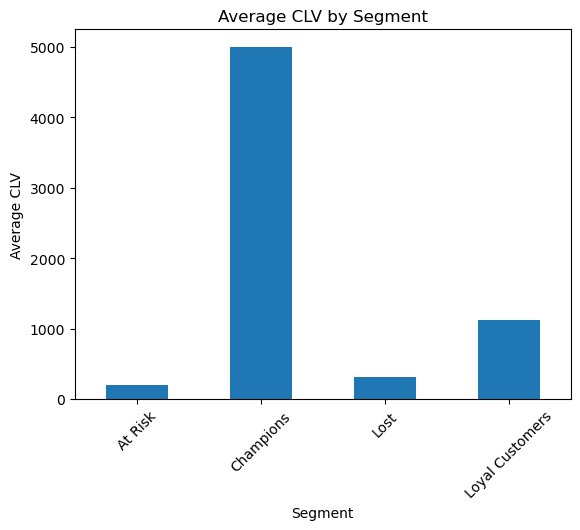

In [6]:
rfm.groupby('Segment')['CLV'].mean().plot(kind='bar')
plt.title('Average CLV by Segment')
plt.ylabel('Average CLV')
plt.xticks(rotation=45)
plt.show()

In [7]:
rfm.groupby('Segment')[['Monetary','CLV']].mean()

,Monetary,CLV
Segment,,
At Risk,419.811479,194.006528
Champions,5130.175070,4998.276206
Lost,488.048452,306.239517
Loyal Customers,1432.833941,1124.542136


In [8]:
import os
path = os.makedirs("../data/processed", exist_ok=True) # Create results directory if it doesn't exist
rfm.to_csv("../data/processed/rfm_with_clv.csv", index=False)

# END